In [52]:
import xarray as xr
import pandas as pd
import numpy as np
from os.path import join

from credit.datasets.goes10km_dataset import GOES10kmDataset

from scipy.interpolate import LinearNDInterpolator

import matplotlib.pyplot as plt


import logging

# Set up logger to print stuff
root = logging.getLogger()
root.setLevel(logging.DEBUG)
formatter = logging.Formatter("%(levelname)s:%(name)s:%(message)s")


# Stream output to stdout
ch = logging.StreamHandler()
# see if we are in debug mode to set logging level
gettrace = getattr(sys, "gettrace", None)
debug = gettrace()
ch.setLevel(logging.INFO)
ch.setFormatter(formatter)
root.addHandler(ch)
logging.debug("logging set to DEBUG level")

In [2]:
test = 0

In [3]:
zarr_ds = xr.open_dataset("/glade/derecho/scratch/dkimpara/goes-cloud-dataset/goes_10km.zarr",
                          consolidated=False,).drop_duplicates(dim="t").sortby("t")
if test:
    zarr_ds = zarr_ds.isel(t=slice(0, 1000))


In [14]:
da = zarr_ds.isel(t=0).BT_or_R

In [19]:
da[4, 200:250,200:250] = np.nan

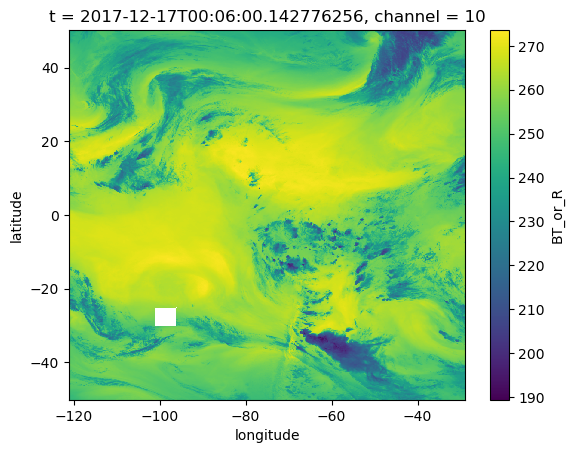

In [21]:
da[4].plot()

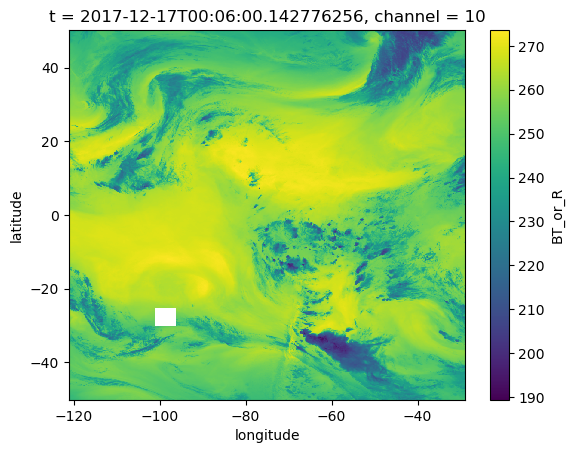

In [55]:
da[4, 200:250,200:250] = np.nan
da[4].plot()

In [56]:
%%time
def fill_na(da):
    lon, lat = np.meshgrid(da.longitude, da.latitude)

    lat_flat, lon_flat = lat.ravel(), lon.ravel()
    coords = np.stack([lat_flat, lon_flat], axis=1)
    
    mask = da[4].notnull().values.ravel()

    data_flat = da[4].values.ravel()
    
    interp = LinearNDInterpolator(
        points=coords[mask],
        values=data_flat[mask],
        fill_value=0,
    )

    result = interp(coords[~mask])

    data_flat[~mask] = result

    da = data_flat.reshape(len(da.latitude), len(da.longitude))
    
    return da
res = fill_na(da)

CPU times: user 13.4 s, sys: 377 ms, total: 13.8 s
Wall time: 14.6 s


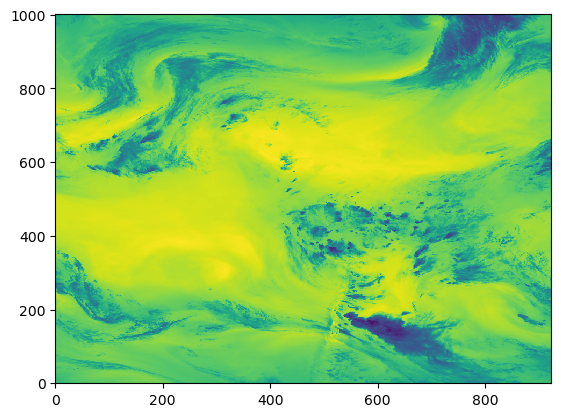

In [57]:
plt.pcolormesh(res)

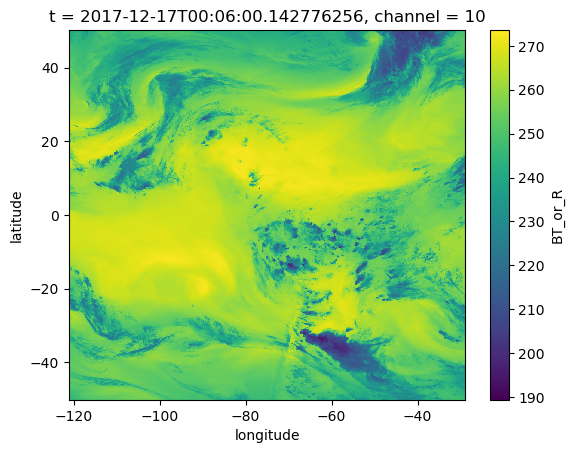

In [54]:
da[4].plot()